# PRÁCTICA EXPERIMENTAL 1 – MINERÍA DE DATOS
## Predicción de la calidad de un vino a partir de sus reseñas (Wine Reviews)

Dataset: https://www.kaggle.com/datasets/zynicide/wine-reviews

**Contenido del cuaderno**
1. Definición del problema
2. Datos: carga, radiografía y análisis exploratorio
3. Preprocesamiento
4. Modelo descriptivo: segmentación con K-Means
5. Modelo predictivo: clasificación (comparación de algoritmos)
6. Evaluación y validación de resultados
7. Conclusiones

# 1. DEFINICIÓN DEL PROBLEMA

**Problema.** Una tienda o distribuidora de vinos recibe miles de referencias y necesita decidir cuáles destacar o comprar. Las reseñas de catadores profesionales (WineEnthusiast) asignan un puntaje de 80 a 100, pero no existen para todos los vinos nuevos.

**Pregunta de investigación.** ¿Se puede predecir si un vino obtendrá **90 puntos o más** ("alta calidad") usando su precio, origen, variedad, antigüedad, catador y el texto de la reseña?

**Objetivos**
- *General:* construir y evaluar modelos de minería de datos que describan y predigan la calidad de los vinos.
- *Específicos:* (1) explorar y depurar el dataset; (2) segmentar los vinos con un modelo descriptivo (K-Means); (3) comparar al menos cinco algoritmos de clasificación; (4) medir qué variables y qué palabras explican la calidad.

**Alcance.** Reseñas de WineEnthusiast hasta 2017 (~130 000 registros, 44 países). Variable objetivo binaria: `high_quality = 1` si `points >= 90`. El modelo no es un sustituto del catador: es una herramienta de priorización.

# CONFIGURACIÓN

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

SEED = 42
sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", 30)

# 2. DATOS

CARGA DEL DATASET DESDE KAGGLE

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "winemag-data-130k-v2.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "zynicide/wine-reviews",
  file_path,
  pandas_kwargs={"index_col": 0},
)

print("Primeros 5 registros:")
df.head()

Primeros 5 registros:


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


REALIZAR LA RADIOGRAFIA DE MIS DATOS CARGADOS

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129908 non-null  str    
 1   description            129971 non-null  str    
 2   designation            92506 non-null   str    
 3   points                 129971 non-null  int64  
 4   price                  120975 non-null  float64
 5   province               129908 non-null  str    
 6   region_1               108724 non-null  str    
 7   region_2               50511 non-null   str    
 8   taster_name            103727 non-null  str    
 9   taster_twitter_handle  98758 non-null   str    
 10  title                  129971 non-null  str    
 11  variety                129970 non-null  str    
 12  winery                 129971 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 12.9 MB


análisis El dataset tiene 129 971 filas y 13 columnas. Solo `points` es entero y `price` es numérica (float); el resto son texto. `description` está completa y es la variable con más información (texto libre). Las columnas `region_2`, `taster_twitter_handle`, `taster_name`, `designation`, `region_1` y `price` tienen valores nulos.

In [4]:
df.describe()

,points,price
count,129971.000000,120975.000000
mean,88.447138,35.363389
std,3.039730,41.022218
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


análisis `points` va de 80 a 100 con media 88.45 y desviación 3.04: los puntajes se concentran en la parte baja del rango (mediana 88, 75 % de los vinos ≤ 91). `price` va de 4 a 3 300 USD con media 35.4 y mediana 25: la media es mayor que la mediana, es decir, hay **sesgo fuerte a la derecha** causado por pocos vinos muy caros. Eso justifica transformar el precio con logaritmo más adelante.

VALORES FALTANTES POR COLUMNA

In [5]:
faltantes = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
faltantes[faltantes > 0]

region_2                 61.14
designation              28.83
taster_twitter_handle    24.02
taster_name              20.19
region_1                 16.35
price                     6.92
province                  0.05
country                   0.05
dtype: float64

análisis `region_2` falta en el 61 % de los registros, por lo que se descartará. `taster_twitter_handle` es solo un alias del catador. `designation` (29 %) y `region_1` (16 %) se convertirán en indicadores binarios (existe / no existe). `price` falta en el 6.9 %: se imputará con la mediana y se agregará un indicador de ausencia, porque que un vino no tenga precio puede ser informativo.

REGISTROS DUPLICADOS

In [6]:
dup = df.duplicated(subset=["description", "title"]).sum()
print(f"Reseñas duplicadas (misma descripción y título): {dup} ({dup/len(df):.1%})")

Reseñas duplicadas (misma descripción y título): 9983 (7.7%)


análisis Hay 9 983 reseñas repetidas (7.7 %). Si se dejaran, el mismo vino podría quedar en entrenamiento y en prueba a la vez y los resultados saldrían inflados. Se eliminarán antes de dividir los datos.

DISTRIBUCIÓN DEL PUNTAJE Y DE LA VARIABLE OBJETIVO

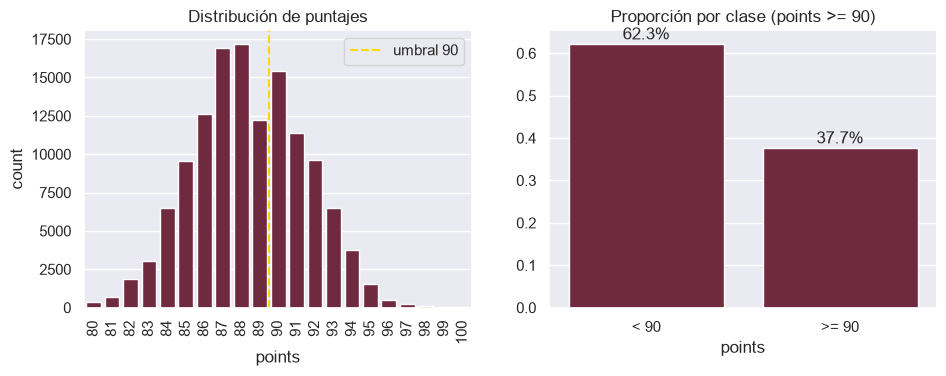

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sns.countplot(x="points", data=df, color="#7B1E3A", ax=ax[0])
ax[0].set_title("Distribución de puntajes")
ax[0].tick_params(axis="x", labelrotation=90)
ax[0].axvline(9.5, color="gold", ls="--", label="umbral 90")
ax[0].legend()

obj = (df.points >= 90).value_counts(normalize=True).rename({False: "< 90", True: ">= 90"})
sns.barplot(x=obj.index, y=obj.values, color="#7B1E3A", ax=ax[1])
ax[1].set_title("Proporción por clase (points >= 90)")
for i, v in enumerate(obj.values):
    ax[1].text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.show()

análisis La distribución del puntaje es casi simétrica con centro en 87-88 y cola larga hacia 100. Con el umbral de 90 puntos la clase "alta calidad" representa ~37.7 % (≈ 38 % tras depurar duplicados): el problema está **moderadamente desbalanceado**, no es extremo, así que bastan métricas como F1 y AUC además de la exactitud. Un clasificador que siempre diga "< 90" acertaría 62 %: ese es el piso (baseline) que debemos superar.

RELACIÓN ENTRE PRECIO Y PUNTAJE

Correlación de Spearman precio-puntos: rho = 0.606 (p = 0.0e+00)


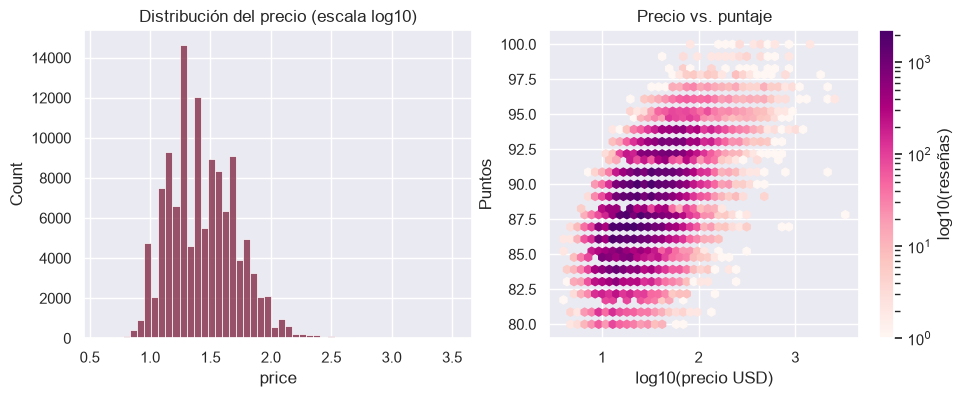

In [8]:
d = df.dropna(subset=["price"])
rho, p = stats.spearmanr(d.price, d.points)
print(f"Correlación de Spearman precio-puntos: rho = {rho:.3f} (p = {p:.1e})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(np.log10(d.price), bins=50, color="#7B1E3A", ax=ax[0])
ax[0].set_title("Distribución del precio (escala log10)")
hb = ax[1].hexbin(np.log10(d.price), d.points, gridsize=40, cmap="RdPu", mincnt=1, bins="log")
plt.colorbar(hb, ax=ax[1], label="log10(reseñas)")
ax[1].set_xlabel("log10(precio USD)"); ax[1].set_ylabel("Puntos"); ax[1].set_title("Precio vs. puntaje")
plt.show()

análisis En escala logarítmica el precio se vuelve casi simétrico. La correlación de Spearman es **0.61**: moderada-fuerte y significativa; los vinos caros tienden a puntuar más, pero hay mucha dispersión (se ven vinos de 15 USD con 92 puntos y vinos de 100 USD con 85). Por eso el precio ayuda pero no alcanza por sí solo para predecir la calidad.

PUNTAJE POR PAÍS

country
US           54504
France       22093
Italy        19540
Spain         6645
Portugal      5691
Chile         4472
Argentina     3800
Austria       3345
Australia     2329
Germany       2165
Name: count, dtype: int64


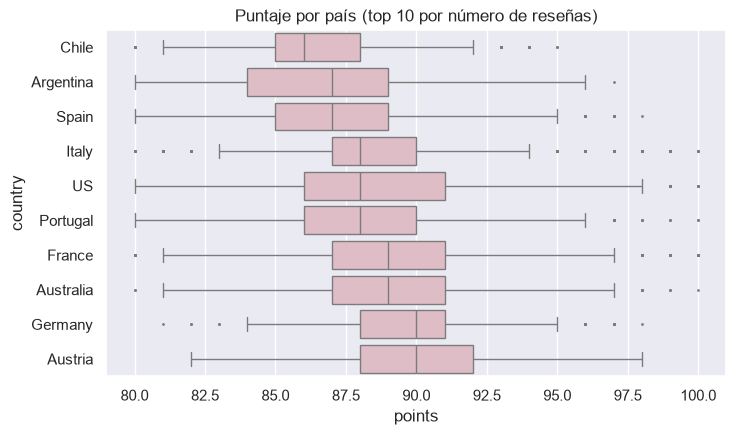

Kruskal-Wallis puntos ~ país: H = 5694, p = 0.00e+00


In [9]:
top_paises = df.country.value_counts().head(10).index
print(df.country.value_counts().head(10))

plt.figure(figsize=(8, 4.5))
orden = df[df.country.isin(top_paises)].groupby("country").points.median().sort_values().index
sns.boxplot(data=df[df.country.isin(top_paises)], y="country", x="points", order=orden, color="#E4B7C3", fliersize=1)
plt.title("Puntaje por país (top 10 por número de reseñas)")
plt.show()

H, p = stats.kruskal(*[df.loc[df.country == c, "points"] for c in top_paises])
print(f"Kruskal-Wallis puntos ~ país: H = {H:.0f}, p = {p:.2e}")

análisis Estados Unidos concentra el 42 % de las reseñas (54 504), seguido de Francia e Italia. Las medianas difieren entre países (Austria y Alemania con mediana 90 arriba; Argentina y Chile con 86 y España con 87 abajo) y la prueba de Kruskal-Wallis rechaza que sean iguales (p ≈ 0). El país aporta información, aunque con mucho solapamiento entre cajas.

PUNTAJE POR CATADOR (POSIBLE SESGO DEL EVALUADOR)

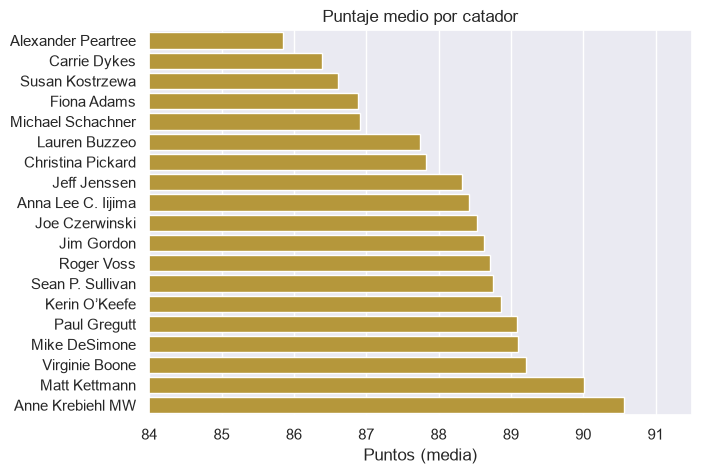

Kruskal-Wallis puntos ~ catador: H = 9634, p = 0.00e+00


In [10]:
tm = df.groupby("taster_name").points.agg(["mean", "count"]).sort_values("mean")
plt.figure(figsize=(7, 5))
sns.barplot(x=tm["mean"], y=tm.index, color="#C9A227")
plt.xlim(84, 91.5); plt.xlabel("Puntos (media)"); plt.ylabel("")
plt.title("Puntaje medio por catador")
plt.show()

H, p = stats.kruskal(*[g.points.values for _, g in df.dropna(subset=["taster_name"]).groupby("taster_name")])
print(f"Kruskal-Wallis puntos ~ catador: H = {H:.0f}, p = {p:.2e}")

análisis Hay 19 catadores y su puntaje medio va de 85.9 (Alexander Peartree) a 90.6 (Anne Krebiehl MW), casi 5 puntos de diferencia. Parte de eso refleja los vinos que le tocó catar a cada uno, pero también estilos de puntuación distintos. Esto es una advertencia de **sesgo del evaluador**; más adelante se mide cuánto depende el modelo de esta variable.

# 3. PREPROCESAMIENTO

ELIMINAR DUPLICADOS Y COLUMNAS SIN VALOR

In [11]:
n0 = len(df)
data = df.drop_duplicates(subset=["description", "title"]).reset_index(drop=True)
data = data.drop(columns=["taster_twitter_handle", "region_2"])
print(f"Filas: {n0} -> {len(data)} ({n0 - len(data)} duplicadas eliminadas)")

Filas: 129971 -> 119988 (9983 duplicadas eliminadas)


análisis Se eliminaron 9 983 duplicados (quedan 119 988 reseñas) y dos columnas: `region_2` (61 % nulos) y `taster_twitter_handle` (redundante con `taster_name`).

TRATAMIENTO DE FALTANTES CATEGÓRICOS

In [12]:
for c in ["country", "province", "taster_name"]:
    data[c] = data[c].fillna("Unknown")
data["description"] = data["description"].str.replace(r"\s+", " ", regex=True).str.strip()
data[["country", "province", "taster_name"]].isna().sum()

country        0
province       0
taster_name    0
dtype: int64

análisis Los pocos nulos de país/provincia y el 20 % de reseñas sin catador se agrupan en la categoría `Unknown`, para no perder esas filas.

PRECIO: RECORTE DE VALORES EXTREMOS, INDICADOR DE AUSENCIA Y LOGARITMO

Percentil 99.9 del precio: 476 USD  |  filas recortadas: 111


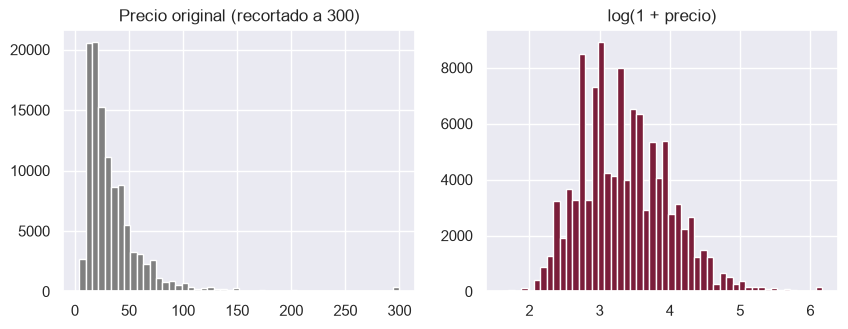

In [13]:
cap = data.price.quantile(0.999)
print(f"Percentil 99.9 del precio: {cap:.0f} USD  |  filas recortadas: {(data.price > cap).sum()}")

data["price_missing"] = data.price.isna().astype(int)
data["log_price"] = np.log1p(data.price.clip(upper=cap))   # la imputación de la mediana se hace dentro del pipeline

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].hist(data.price.dropna().clip(upper=300), bins=50, color="grey"); ax[0].set_title("Precio original (recortado a 300)")
ax[1].hist(data.log_price.dropna(), bins=50, color="#7B1E3A"); ax[1].set_title("log(1 + precio)")
plt.show()

análisis Solo 111 vinos superan los 476 USD (percentil 99.9); se recortan para que no dominen la escala. El logaritmo convierte la distribución sesgada en una campana casi simétrica, adecuada para modelos lineales y distancias (K-Means). La imputación de la mediana no se hace aquí sino dentro del pipeline de entrenamiento, para evitar **fuga de información** del conjunto de prueba.

EDAD DEL VINO: EXTRAER LA COSECHA DESDE EL TÍTULO

In [14]:
def cosecha(titulo):
    anios = re.findall(r"\b(19[5-9]\d|20[01]\d)\b", titulo)
    return int(anios[-1]) if anios else np.nan

REF_YEAR = 2017  # último año de cosecha presente en el dataset
data["year"] = data.title.map(cosecha)
data.loc[data.year > REF_YEAR, "year"] = np.nan
data["age_missing"] = data.year.isna().astype(int)
data["age"] = REF_YEAR - data.year

print(f"Cosecha extraída en el {100 * (1 - data.age_missing.mean()):.1f}% de los vinos")
data.age.describe()

Cosecha extraída en el 96.4% de los vinos


count    115694.000000
mean          6.415130
std           3.690514
min           0.000000
25%           4.000000
50%           6.000000
75%           8.000000
max          66.000000
Name: age, dtype: float64

análisis Se obtuvo la cosecha en el 96.4 % de los títulos mediante una expresión regular. Con ella se creó la variable `age` (2017 − cosecha): la mayoría de vinos tiene pocos años y unos pocos superan los 30, lo que da una variable nueva y útil que no existía en el dataset original.

VARIABLES DERIVADAS DEL TEXTO Y DEL METADATO + VARIABLE OBJETIVO

In [15]:
data["desc_len_chars"] = data.description.str.len()
data["desc_words"] = data.description.str.split().str.len()
data["has_designation"] = data.designation.notna().astype(int)
data["has_region"] = data.region_1.notna().astype(int)
data["high_quality"] = (data.points >= 90).astype(int)

print(data.high_quality.value_counts(normalize=True).round(3))
print()
print(data.groupby("high_quality")[["desc_len_chars", "desc_words", "price"]].median())

high_quality
0    0.62
1    0.38
Name: proportion, dtype: float64

              desc_len_chars  desc_words  price
high_quality                                   
0                      216.0        36.0   20.0
1                      276.0        45.0   42.0


análisis Tras depurar, la clase positiva (≥ 90 puntos) es el **38.0 %**. Hay un hallazgo importante: los vinos de alta calidad tienen reseñas más largas (mediana de palabras claramente mayor). Los catadores escriben más cuando el vino los impresiona; la longitud de la reseña se convierte en una de las variables más predictivas (se confirma en la evaluación).

# 4. MODELO DESCRIPTIVO: SEGMENTACIÓN CON K-MEANS

ELEGIR EL NÚMERO DE CLUSTERS (CODO Y SILUETA)

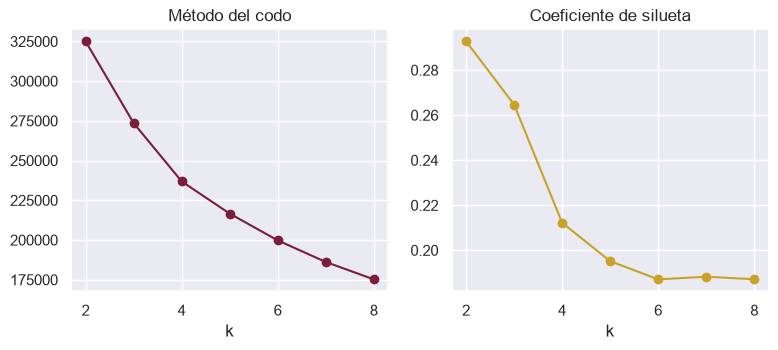

{2: 0.293, 3: 0.265, 4: 0.212, 5: 0.195, 6: 0.187, 7: 0.188, 8: 0.187}


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

feats_km = ["points", "log_price", "age", "desc_words"]
Xk = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(data[feats_km]))
idx = np.random.RandomState(SEED).choice(len(Xk), 15000, replace=False)

ks, inercia, sil = range(2, 9), [], []
for k in ks:
    km = KMeans(k, n_init=10, random_state=SEED).fit(Xk)
    inercia.append(km.inertia_)
    sil.append(silhouette_score(Xk[idx], km.labels_[idx]))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(ks, inercia, "o-", color="#7B1E3A"); ax[0].set_title("Método del codo"); ax[0].set_xlabel("k")
ax[1].plot(ks, sil, "o-", color="#C9A227"); ax[1].set_title("Coeficiente de silueta"); ax[1].set_xlabel("k")
plt.show()
print({k: round(s, 3) for k, s in zip(ks, sil)})

análisis La silueta es máxima con k = 2 (0.29) y decae después; con k = 4 vale 0.195 (estructura moderada, los grupos se solapan porque el vino es un continuo de calidad y no categorías separadas). Se elige **k = 4** porque a partir de ahí la silueta ya no cae de forma marcada (0.195 → 0.187) y permite una interpretación comercial más rica que solo "bueno / malo". Es una decisión de interpretabilidad, no de máxima silueta.

PERFIL DE CADA CLUSTER

In [17]:
km = KMeans(4, n_init=20, random_state=SEED).fit(Xk)
data["cluster"] = km.labels_

perfil = data.groupby("cluster").agg(
    n=("points", "size"), puntos=("points", "mean"), precio_mediano=("price", "median"),
    edad=("age", "mean"), palabras=("desc_words", "mean"), prop_alta_calidad=("high_quality", "mean"),
).round(2)
perfil["pais_top"] = data.groupby("cluster").country.agg(lambda s: s.value_counts().index[0])
perfil["variedad_top"] = data.groupby("cluster").variety.agg(lambda s: s.value_counts().index[0])
perfil["%"] = (100 * perfil.n / len(data)).round(1)
perfil.sort_values("puntos", ascending=False)

,n,puntos,precio_mediano,edad,palabras,prop_alta_calidad,pais_top,variedad_top,%
cluster,,,,,,,,,
1,23798,92.21,60.0,6.49,52.19,0.93,US,Pinot Noir,19.8
0,41161,89.29,27.0,4.52,40.65,0.46,US,Pinot Noir,34.3
2,19484,87.61,25.0,11.89,42.44,0.23,US,Cabernet Sauvignon,16.2
3,35545,85.40,15.0,5.41,31.16,0.00,US,Chardonnay,29.6


análisis Los cuatro segmentos son interpretables:
- **Premium** (≈ 20 %): 92.2 puntos, precio mediano 60 USD, reseñas largas (52 palabras), 93 % de alta calidad, dominado por Pinot Noir.
- **Buena relación calidad-precio** (≈ 34 %): 89.3 puntos y 27 USD; 46 % supera los 90.
- **Vinos maduros** (≈ 16 %): edad media de 11.9 años, 87.6 puntos, mayormente Cabernet Sauvignon; solo 23 % alta calidad.
- **Económicos** (≈ 30 %): 85.4 puntos, 15 USD y reseñas cortas (31 palabras), 0 % de alta calidad (Chardonnay).

El precio y el largo de la reseña crecen junto con el puntaje, lo que anticipa lo que verá el modelo predictivo.

VISUALIZACIÓN DE LOS CLUSTERS (PCA)

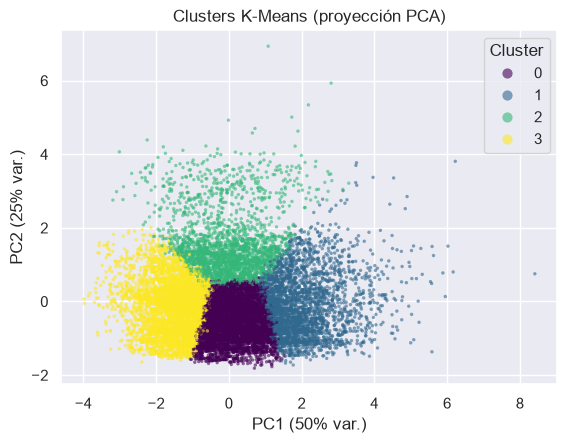

In [18]:
pca = PCA(2, random_state=SEED).fit(Xk)
Z = pca.transform(Xk[idx])
plt.figure(figsize=(6.4, 4.6))
sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=km.labels_[idx], palette="viridis", s=6, alpha=.6, linewidth=0)
plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.0f}% var.)"); plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.0f}% var.)")
plt.title("Clusters K-Means (proyección PCA)"); plt.legend(title="Cluster", markerscale=3)
plt.show()

análisis En el plano de los dos primeros componentes los clusters forman una banda continua ordenada por calidad, con fronteras que se tocan. Confirma la silueta moderada: la segmentación es útil para describir el catálogo, no para separar grupos "naturales".

# 5. MODELO PREDICTIVO: CLASIFICACIÓN DE ALTA CALIDAD (≥ 90 PUNTOS)

DIVISIÓN ENTRENAMIENTO / PRUEBA (80 / 20, ESTRATIFICADA)

In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

NUM = ["log_price", "age", "desc_len_chars", "desc_words"]
BIN = ["price_missing", "age_missing", "has_designation", "has_region"]
CAT = ["country", "province", "variety", "taster_name"]
TEXT = "description"
TARGET = "high_quality"

X, y = data[NUM + BIN + CAT + [TEXT]], data[TARGET]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Entrenamiento:", Xtr.shape, "| Prueba:", Xte.shape)
print("Proporción de positivos:", round(ytr.mean(), 3), "/", round(yte.mean(), 3))

Entrenamiento: (95990, 13) | Prueba: (23998, 13)
Proporción de positivos: 0.38 / 0.38


análisis Se reservó el 20 % (23 998 reseñas) para la prueba final, que no se toca hasta evaluar. La estratificación mantiene 38 % de positivos en ambos conjuntos. Todo el preprocesamiento que aprende de los datos (mediana, escalado, categorías, TF-IDF) se ajusta únicamente con el conjunto de entrenamiento dentro de los pipelines.

PIPELINES Y MODELOS CANDIDATOS

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier

def prep_linear(text=False):
    t = [("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUM),
         ("bin", "passthrough", BIN),
         ("cat", OneHotEncoder(min_frequency=200, handle_unknown="infrequent_if_exist"), CAT)]
    if text:
        t.append(("txt", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=5,
                                         sublinear_tf=True, stop_words="english"), TEXT))
    return ColumnTransformer(t)

prep_gb = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan,
                           min_frequency=200, encoded_missing_value=np.nan), CAT),
    ("num", "passthrough", NUM), ("bin", "passthrough", BIN)])

modelos = {
    "Baseline (clase mayoritaria)": Pipeline([("prep", prep_linear()), ("clf", DummyClassifier(strategy="most_frequent"))]),
    "Regresión logística (tabular)": Pipeline([("prep", prep_linear()), ("clf", LogisticRegression(max_iter=1000))]),
    "Árbol de decisión": Pipeline([("prep", prep_linear()), ("clf", DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=50, random_state=SEED))]),
    "Random Forest": Pipeline([("prep", prep_linear()), ("clf", RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5, max_features="sqrt", n_jobs=-1, random_state=SEED))]),
    # hiperparámetros obtenidos con GridSearchCV (ver src/04_modeling.py)
    "Gradient Boosting (ajustado)": Pipeline([("prep", prep_gb), ("clf", HistGradientBoostingClassifier(
        learning_rate=0.05, max_leaf_nodes=63, l2_regularization=1.0, max_iter=300, early_stopping=True,
        validation_fraction=0.1, categorical_features=[0, 1, 2, 3], random_state=SEED))]),
    "Regresión logística + TF-IDF": Pipeline([("prep", prep_linear(text=True)), ("clf", LogisticRegression(
        max_iter=2000, C=1.0))]),
}
list(modelos)

['Baseline (clase mayoritaria)',
 'Regresión logística (tabular)',
 'Árbol de decisión',
 'Random Forest',
 'Gradient Boosting (ajustado)',
 'Regresión logística + TF-IDF']

análisis Se comparan seis enfoques de complejidad creciente: un *baseline* que siempre predice la clase mayoritaria, un modelo lineal, un árbol, un bosque aleatorio, *gradient boosting* (con categorías nativas) y una regresión logística que además lee el texto de la reseña con TF-IDF (unigramas y bigramas). Los hiperparámetros de boosting y de la regresión con texto se eligieron con `GridSearchCV` (3 folds, AUC) en el script `src/04_modeling.py`.

VALIDACIÓN CRUZADA (5 FOLDS) SOBRE EL CONJUNTO DE ENTRENAMIENTO

In [21]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

filas = []
for nombre, m in modelos.items():
    r = cross_validate(m, Xtr, ytr, cv=cv, scoring=scoring, n_jobs=1)
    filas.append({"modelo": nombre,
                  **{f"{k}": f"{r[f'test_{k}'].mean():.4f} ± {r[f'test_{k}'].std():.4f}" for k in scoring},
                  "auc_media": r["test_roc_auc"].mean()})
    print(f"{nombre:34s} AUC = {r['test_roc_auc'].mean():.4f}", flush=True)

cv_df = pd.DataFrame(filas).sort_values("auc_media", ascending=False).drop(columns="auc_media")
cv_df

Baseline (clase mayoritaria)       AUC = 0.5000


Regresión logística (tabular)      AUC = 0.8861


Árbol de decisión                  AUC = 0.8704


Random Forest                      AUC = 0.8927


Gradient Boosting (ajustado)       AUC = 0.9020


Regresión logística + TF-IDF       AUC = 0.9431


,modelo,accuracy,f1,roc_auc
5,Regresión logística + TF-IDF,0.8677 ± 0.0024,0.8223 ± 0.0031,0.9431 ± 0.0010
4,Gradient Boosting (ajustado),0.8221 ± 0.0020,0.7630 ± 0.0032,0.9020 ± 0.0020
3,Random Forest,0.8132 ± 0.0021,0.7442 ± 0.0030,0.8927 ± 0.0016
1,Regresión logística (tabular),0.8067 ± 0.0021,0.7336 ± 0.0031,0.8861 ± 0.0021
2,Árbol de decisión,0.7949 ± 0.0033,0.7223 ± 0.0076,0.8704 ± 0.0024
0,Baseline (clase mayoritaria),0.6200 ± 0.0000,0.0000 ± 0.0000,0.5000 ± 0.0000


análisis Resultados en validación cruzada (AUC): baseline 0.500 → árbol 0.870 → regresión logística 0.886 → Random Forest 0.893 → Gradient Boosting 0.902 → **regresión logística + TF-IDF 0.943**. Las desviaciones entre folds son pequeñas (≈ 0.002), así que las diferencias son estables. Lo más importante: **añadir el texto sube el AUC en ~4 puntos**, más que cualquier cambio de algoritmo sobre las variables tabulares. En este problema la información está en lo que dice la reseña, no en el modelo usado.

# 6. EVALUACIÓN

ENTRENAR CON TODO EL ENTRENAMIENTO Y MEDIR EN EL CONJUNTO DE PRUEBA

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, matthews_corrcoef, confusion_matrix, roc_curve, precision_recall_curve)

proba, filas = {}, []
for nombre, m in modelos.items():
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    proba[nombre] = p
    pred = (p >= 0.5).astype(int)
    filas.append({"modelo": nombre, "accuracy": accuracy_score(yte, pred), "precision": precision_score(yte, pred, zero_division=0),
                  "recall": recall_score(yte, pred), "f1": f1_score(yte, pred), "mcc": matthews_corrcoef(yte, pred),
                  "roc_auc": roc_auc_score(yte, p), "pr_auc": average_precision_score(yte, p)})

test_df = pd.DataFrame(filas).sort_values("roc_auc", ascending=False).round(4)
test_df

,modelo,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc
5,Regresión logística + TF-IDF,0.8652,0.8344,0.8051,0.8195,0.7123,0.9423,0.9115
4,Gradient Boosting (ajustado),0.8177,0.7660,0.7491,0.7575,0.6116,0.8998,0.8447
3,Random Forest,0.8104,0.7708,0.7128,0.7407,0.5927,0.8899,0.8320
1,Regresión logística (tabular),0.8064,0.7676,0.7032,0.7340,0.5836,0.8851,0.8234
2,Árbol de decisión,0.7942,0.7378,0.7109,0.7241,0.5603,0.8680,0.7970
0,Baseline (clase mayoritaria),0.6201,0.0000,0.0000,0.0000,0.0000,0.5000,0.3799


análisis En el conjunto de prueba (23 998 reseñas nunca vistas) el mejor modelo es la **regresión logística con TF-IDF: exactitud 86.5 %, F1 0.820, AUC 0.942**, frente a 62 % de exactitud del baseline. Los resultados de prueba coinciden con los de validación cruzada (no hay sobreajuste). Con precisión 0.83 y recall 0.81, de cada 100 vinos que el modelo marca como "alta calidad" 83 lo son, y detecta 81 de cada 100 que realmente lo son. Los modelos solo tabulares quedan en AUC 0.87-0.90. Un ensamble por *stacking* (texto + boosting, ver `src/04_modeling.py`) alcanza AUC 0.9425, una mejora de apenas 0.0002, es decir, no justifica su costo.

CURVAS ROC Y PRECISIÓN-RECALL

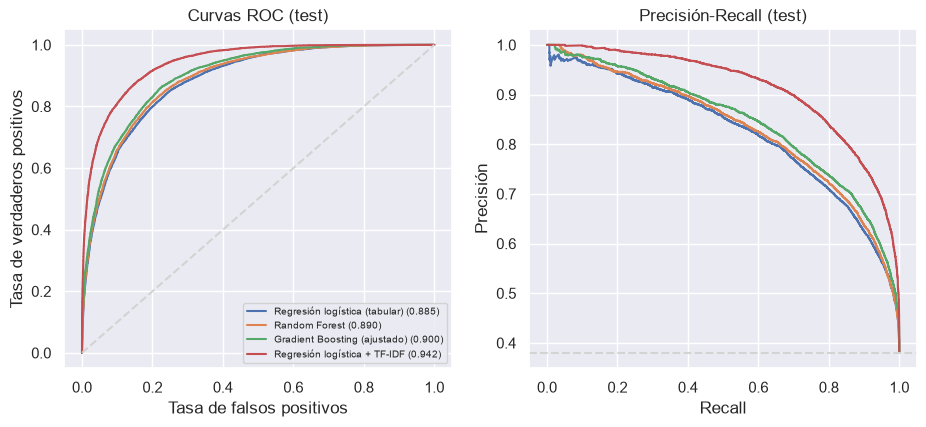

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for nombre in ["Regresión logística (tabular)", "Random Forest", "Gradient Boosting (ajustado)", "Regresión logística + TF-IDF"]:
    fpr, tpr, _ = roc_curve(yte, proba[nombre]); ax[0].plot(fpr, tpr, label=f"{nombre} ({roc_auc_score(yte, proba[nombre]):.3f})")
    pr, rc, _ = precision_recall_curve(yte, proba[nombre]); ax[1].plot(rc, pr, label=nombre)
ax[0].plot([0, 1], [0, 1], "--", color="lightgrey"); ax[0].set_title("Curvas ROC (test)"); ax[0].legend(fontsize=7, loc="lower right")
ax[0].set_xlabel("Tasa de falsos positivos"); ax[0].set_ylabel("Tasa de verdaderos positivos")
ax[1].axhline(yte.mean(), ls="--", color="lightgrey"); ax[1].set_title("Precisión-Recall (test)")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precisión")
plt.show()

análisis La curva del modelo con texto domina a las demás en todo el rango: para cualquier tasa de falsos positivos, detecta más vinos buenos. En Precisión-Recall (más informativa con clases desbalanceadas) mantiene precisión 0.90 con recall 0.70 y 0.84 con recall 0.80, muy por encima de la línea base de 0.38. Por ejemplo, con 5 % de falsos positivos detecta 70 % de los vinos buenos, frente a 54 % del boosting tabular.

MATRIZ DE CONFUSIÓN DEL MEJOR MODELO

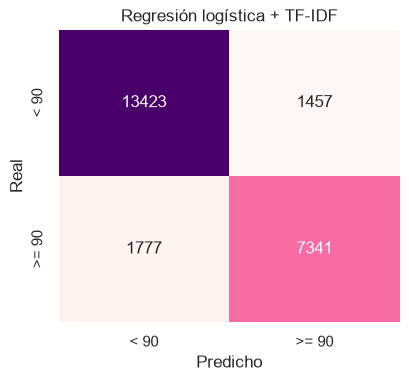

In [24]:
mejor = "Regresión logística + TF-IDF"
cm = confusion_matrix(yte, (proba[mejor] >= 0.5).astype(int))
plt.figure(figsize=(4.4, 3.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", cbar=False, xticklabels=["< 90", ">= 90"], yticklabels=["< 90", ">= 90"])
plt.xlabel("Predicho"); plt.ylabel("Real"); plt.title(mejor)
plt.show()

análisis El modelo comete más errores del tipo "falso negativo" (vinos de ≥ 90 clasificados como < 90) que "falso positivo", coherente con un recall (0.81) algo menor que la precisión (0.83). Hay 1 773 falsos negativos frente a 1 458 falsos positivos. Los errores se concentran en los vinos cercanos al umbral: el 72 % de los errores corresponde a vinos de 89, 90 o 91 puntos (tasa de error de 33 % en los de 89 y 43 % en los de 90, frente a menos de 3 % por debajo de 86), donde incluso dos catadores podrían discrepar.

QUÉ PALABRAS DISTINGUEN UN VINO DE ≥ 90 PUNTOS

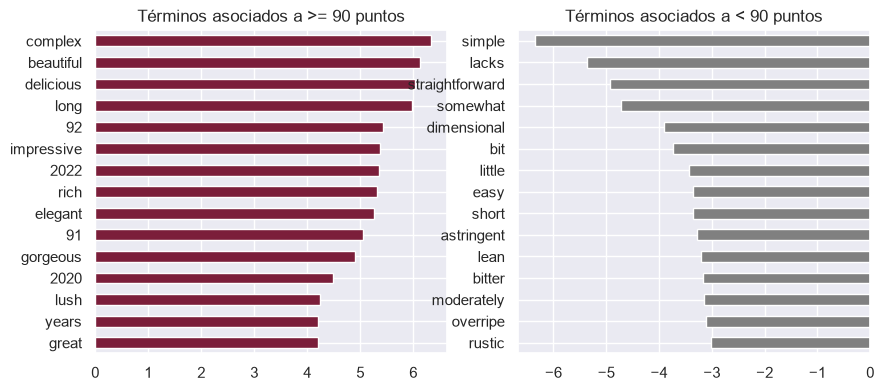

In [25]:
lr = modelos[mejor]
nombres = lr.named_steps["prep"].get_feature_names_out()
coef = pd.Series(lr.named_steps["clf"].coef_[0], index=nombres)
coef = coef[coef.index.str.startswith("txt__")]; coef.index = coef.index.str[5:]

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
coef.nlargest(15)[::-1].plot.barh(color="#7B1E3A", ax=ax[0]); ax[0].set_title("Términos asociados a >= 90 puntos")
coef.nsmallest(15)[::-1].plot.barh(color="grey", ax=ax[1]); ax[1].set_title("Términos asociados a < 90 puntos")
plt.show()

análisis El modelo aprendió el vocabulario del catador. Suman hacia alta calidad: *complex, beautiful, delicious, long, impressive, elegant, rich, gorgeous, lush*. Restan: *simple, lacks, straightforward, somewhat, bit, little, easy, short, astringent*. Es lógico: adjetivos de riqueza y complejidad vs. calificativos de ausencia o atenuación. Los años 2020 y 2022 también suman: son ventanas de consumo ("drink through 2022"), propias de vinos con potencial de guarda. Se verificó que los números 80-100 aparecen en solo 3.3 % de las descripciones y casi siempre son porcentajes de mezcla de uvas (no el puntaje), por lo que **no hay fuga directa de la etiqueta**.

IMPORTANCIA DE LAS VARIABLES TABULARES (PERMUTACIÓN)

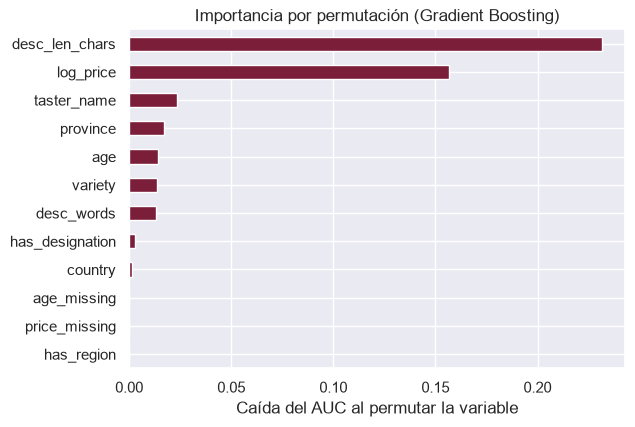

In [26]:
from sklearn.inspection import permutation_importance

gb = modelos["Gradient Boosting (ajustado)"]
muestra = np.random.RandomState(SEED).choice(len(Xte), 6000, replace=False)
feats = NUM + BIN + CAT
pi = permutation_importance(gb, Xte.iloc[muestra][feats + [TEXT]], yte.iloc[muestra], scoring="roc_auc",
                            n_repeats=5, random_state=SEED, n_jobs=1)
imp = pd.Series(pi.importances_mean, index=feats + [TEXT]).drop(TEXT).sort_values()

plt.figure(figsize=(6.4, 4.4))
imp.plot.barh(color="#7B1E3A")
plt.xlabel("Caída del AUC al permutar la variable"); plt.title("Importancia por permutación (Gradient Boosting)")
plt.show()

análisis La variable más influyente es la **longitud de la reseña** (`desc_len_chars`: el AUC cae 0.23 al permutarla), seguida del **precio** (0.16). Muy por detrás: catador (0.024), provincia (0.017), edad (0.014) y variedad (0.014). El país casi no aporta una vez conocidos precio y provincia. Un modelo de boosting entrenado **sin** el catador pierde solo 0.003 de AUC (0.8998 → 0.8965): el modelo no depende de quién cató el vino, lo que atenúa la preocupación por el sesgo del evaluador.

ANÁLISIS DE ERRORES SEGÚN RANGO DE PRECIO

In [27]:
e = Xte.copy()
e["y"] = yte.values
e["pred"] = (proba[mejor] >= 0.5).astype(int)
e["error"] = (e.y != e.pred).astype(int)
e["rango_precio"] = pd.cut(np.expm1(e.log_price), [0, 15, 30, 60, 120, 1e5], labels=["<15", "15-30", "30-60", "60-120", ">120"])
print("Tasa de error por rango de precio (USD):")
print(e.groupby("rango_precio", observed=True).error.mean().round(3))
print("\nError en vinos sin precio:", round(e[e.price_missing == 1].error.mean(), 3))

Tasa de error por rango de precio (USD):
rango_precio
<15       0.042
15-30     0.159
30-60     0.176
60-120    0.118
>120      0.075
Name: error, dtype: float64

Error en vinos sin precio: 0.164


análisis El modelo falla poco en los extremos (4 % de error en vinos < 15 USD, que casi nunca llegan a 90; 7.5 % en > 120 USD, que casi siempre sí) y falla más en la zona media de 15 a 60 USD (16-18 %), donde conviven vinos buenos y regulares. Es el comportamiento esperado: la incertidumbre está en el medio.

# 7. CONCLUSIONES

1. **Es posible predecir la alta calidad de un vino con buena precisión**: el mejor modelo (regresión logística + TF-IDF) logra 86.5 % de exactitud, F1 0.82 y AUC 0.94 en datos no vistos, frente a 62 % del baseline.
2. **El texto de la reseña aporta más que cualquier algoritmo sofisticado**: pasar de variables tabulares a texto mejora el AUC de ~0.90 a ~0.94; cambiar de árbol a boosting solo aporta ~0.03.
3. **Las variables más influyentes son la longitud de la reseña y el precio**; el catador pesa poco una vez conocidas las demás variables.
4. **La segmentación K-Means** produce cuatro perfiles interpretables (Premium, Calidad-precio, Maduros, Económicos), aunque con fronteras difusas (silueta 0.195).
5. **Limitaciones:** el dataset solo cubre reseñas de una revista hasta 2017; el puntaje es subjetivo; la reseña se escribe *después* de catar el vino, por lo que el modelo sirve para analizar y priorizar, no para predecir la calidad de un vino sin reseña; y el umbral de 90 puntos es una decisión de negocio.
6. **Trabajo futuro:** embeddings de lenguaje (BERT), regresión sobre el puntaje exacto y validación con reseñas posteriores a 2017.

Código completo y reproducible en el repositorio de GitHub (carpeta `src/`).